<a href="https://colab.research.google.com/github/corrielynnyuill-debug/Assignment11-CLY/blob/main/Assignment11_CorrieLynnYuill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Flatten label arrays
y_train = y_train.flatten()
y_test = y_test.flatten()

# Normalize pixel values (0-1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten images for Random Forest
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# Display Final train/test sets for modeling
print('Training set shape:', X_train_scaled.shape)
print('Test set shape:', X_test_scaled.shape)
print('Number of classes', len(np.unique(y_train)))


Training set shape: (50000, 3072)
Test set shape: (10000, 3072)
Number of classes 10


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy: 0.4468
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.56      0.55      1000
           1       0.48      0.52      0.50      1000
           2       0.34      0.33      0.34      1000
           3       0.31      0.27      0.29      1000
           4       0.37      0.38      0.37      1000
           5       0.39      0.36      0.37      1000
           6       0.48      0.51      0.49      1000
           7       0.49      0.43      0.46      1000
           8       0.56      0.60      0.58      1000
           9       0.47      0.50      0.49      1000

    accuracy                           0.45     10000
   macro avg       0.44      0.45      0.44     10000
weighted avg       0.44      0.45      0.44     10000



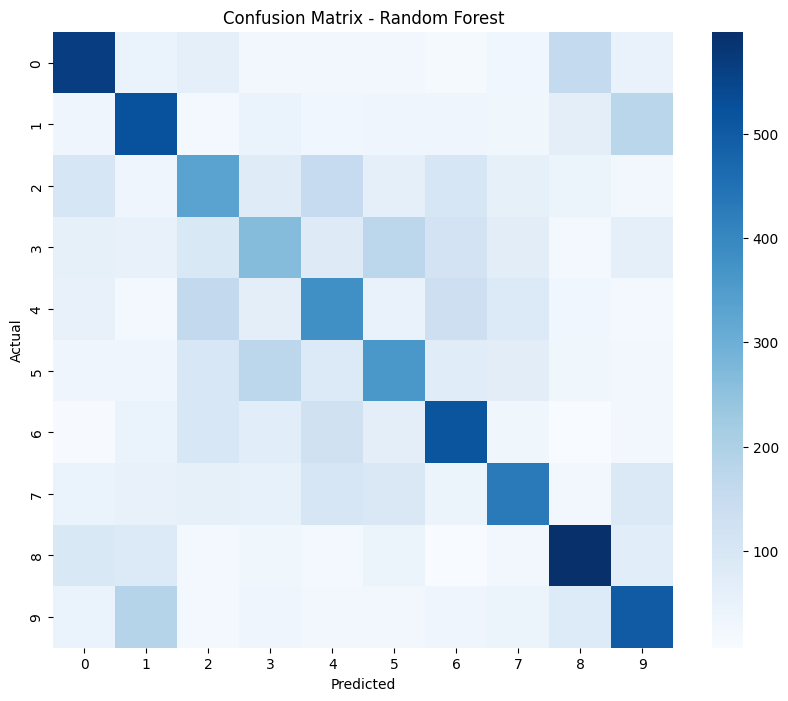

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define parameter gird
param_grid = {
    'n_estimators': [50],
    'max_depth': [None, 20],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

# Create Random Forest Model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid Search with 3-fold CV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

# Best Parameters and best model
print('Best Parameters:', grid_search.best_params_)
best_rf = grid_search.best_estimator_

# Predictions
y_pred = best_rf.predict(X_test_scaled)

# Evaluation metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Feature Importance Plot Top 20
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-20]

plt.figure(figsize=(10, 6))
plt.bar(range(len(20)), importances[indices], color='blue')
plt.xticks(range(20), indices, rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()



In [ ]:
from tensorflow.keras.preprocessing import image

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog',
               'horse', 'ship', 'truck']

def predict_new_image(img_path):
  # Load image
  img = image.load_img(img_path, target_size=(32, 32))
  #Convert to array
  img_array = image.img_to_array(img)
  # Normalize
  img_array = img_array.astype('float32') / 255.0
  # Flatten
  img_flat = img_array.reshape(1, -1)
  # Scale using using scaler in code cell 1
  img_scaled = scaler.transform(img_flat)
  # Predict
  pred = best_rf.predict(img_scaled)[0]

  print(f'Prediction: {class_names[pred]}')



# Usage
predict_new_image('https://raw.githubusercontent.com/corrielynnyuill-debug/Assignment11-CLY/main/test_image_1.jpg')
predict_new_image('https://raw.githubusercontent.com/corrielynnyuill-debug/Assignment11-CLY/main/test_image_2.jpg')
predict_new_image('https://raw.githubusercontent.com/corrielynnyuill-debug/Assignment11-CLY/main/test_image_3.jpg')
predict_new_image('https://raw.githubusercontent.com/corrielynnyuill-debug/Assignment11-CLY/main/test_image_4.jpg')
predict_new_image('https://raw.githubusercontent.com/corrielynnyuill-debug/Assignment11-CLY/main/test_image_5.jpg')